In [2]:
from quantum import *
from random_functions import *
from matplotlib import color_sequences
from matplotlib import pyplot as plt
from scipy.special import expit as sigmoid
from tqdm import tqdm

In [3]:
rng = qml.numpy.random.default_rng(42)
device = qml.device('default.qubit', wires=N_QUBITS)

def mse_loss(circuit: qml.Qnode, theta: np.ndarray, collocation_points: np.ndarray, target: Callable) -> float:
    """
    Calculates the mean squared error between a parametrised circuit and a target function at a set of collocation points
    """
    return qml.numpy.mean((circuit(collocation_points, theta) - target(collocation_points))**2)

#### Define the target functions

In [4]:
# number of random instances per target function
n_target_instances = 3

target_dict = {
    "Single Pauli Z": [generate_random_instance(single_pauli_z_circuit, device, rng) for _ in range(n_target_instances)],
    "Triple Pauli Z": [generate_random_instance(triple_pauli_z_circuit, device, rng) for _ in range(n_target_instances)],
    "Pauli Combination": [generate_random_instance(optimal_pauli_combination_circuit, device, rng) for _ in range(n_target_instances)],
    "Optimal Spectrum": [generate_random_instance(optimal_spectrum_diagonal_circuit, device, rng) for _ in range(n_target_instances)],
    "Random Series": [generate_random_fourier_series(1, rng), generate_random_fourier_series(3, rng), generate_random_fourier_series(10, rng)],
    "Polynomials": [generate_random_polynomial(1, rng), generate_random_polynomial(2, rng), generate_random_polynomial(3, rng)],
    "Exp Cos": [generate_exp_cos(3, 0.05), generate_exp_cos(8, 0.05), generate_exp_cos(20, 0.02)],
    "Special": [np.sqrt, lambda x: np.exp(x)/100, lambda x: sigmoid(x-np.pi)],
}
for key, val in target_dict.items():
    assert len(val) == n_target_instances, f"target_dict[{key}] has length {len(val)}, where it should have length {n_target_instances}"

#### Do the fitting

In [26]:
n_steps = 1000
stepsize = 0.01

loss_values = np.zeros(shape=(len(target_dict), n_target_instances, n_steps))
final_params = np.zeros(shape=(len(target_dict), n_target_instances, 12*N_QUBITS))
iteration_order = []

circuit = qml.QNode(optimal_spectrum_more_parameters_circuit, device)
collocation_points = np.linspace(0, 2*np.pi, 30) # 75 collocation points for the engineered spectrum model
xs = np.linspace(0, 2*np.pi, 1000)

for target_idx, (target_name, target_list) in enumerate(target_dict.items()):
    if target_idx > 0: print()
    print(f"Fitting model to target {target_name} ({target_idx + 1}/{len(target_dict)})")
    iteration_order.append(target_name)

    for instance_idx, target in enumerate(target_list):
        cost = lambda theta: mse_loss(circuit, theta, collocation_points, target)
        optimiser = qml.AdamOptimizer(stepsize=stepsize)
        theta = rng.uniform(0, 2*np.pi, size=12*N_QUBITS, requires_grad=True)

        for step in tqdm(range(n_steps), total=n_steps):
            theta, loss_values[target_idx,instance_idx,step] = optimiser.step_and_cost(cost, theta)

        final_params[target_idx,instance_idx] = theta.copy()

Fitting model to target Single Pauli Z (1/8)


100%|██████████| 1000/1000 [00:40<00:00, 24.88it/s]



Fitting model to target Triple Pauli Z (2/8)


100%|██████████| 1000/1000 [00:35<00:00, 28.27it/s]



Fitting model to target Pauli Combination (3/8)


...

100%|██████████| 1000/1000 [00:26<00:00, 37.82it/s]



Fitting model to target Exp Cos (7/8)


100%|██████████| 1000/1000 [00:26<00:00, 38.19it/s]



Fitting model to target Special (8/8)


100%|██████████| 1000/1000 [00:26<00:00, 37.91it/s]


Single Pauli Z.0: Training 0.000 Test 0.00823086177386828
Single Pauli Z.1: Training 0.000 Test 0.021683455448911426
Single Pauli Z.2: Training 0.000 Test 0.005224729191225049
Triple Pauli Z.0: Training 0.297 Test 1.110962045663613
Triple Pauli Z.1: Training 0.127 Test 0.3397836104844196
Triple Pauli Z.2: Training 0.000 Test 0.00012095868500583103
Pauli Combination.0: Training 0.026 Test 0.04518536701339739
Pauli Combination.1: Training 0.000 Test 0.030711528166968392
Pauli Combination.2: Training 0.029 Test 0.029028526579478763
Optimal Spectrum.0: Training 0.003 Test 0.37718986862194837
Optimal Spectrum.1: Training 0.001 Test 0.0262621645184501
Optimal Spectrum.2: Training 0.000 Test 0.02376291649664182
Random Series.0: Training 0.000 Test 0.1250035792258465
Random Series.1: Training 0.074 Test 1.8103111460632162
Random Series.2: Training 6.346 Test 8.666891315239349
Polynomials.0: Training 0.042 Test 0.09963578233305605
Polynomials.1: Training 2.500 Test 6.721480448107683
Polynomials

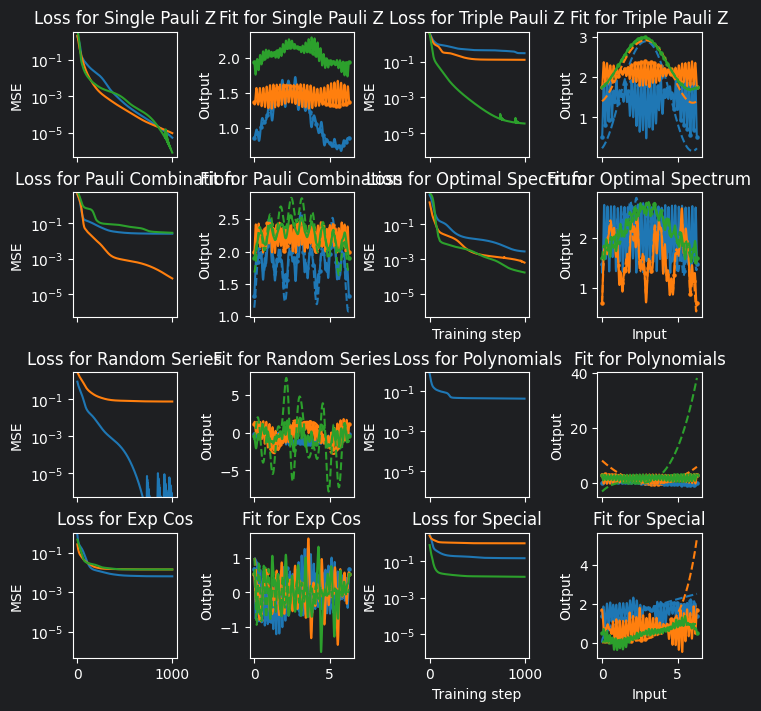

In [28]:
fig, axes = plt.subplots(4, 4, sharex='col', figsize=(7,7), layout='constrained')
axes = np.array(axes).reshape(8,2) # reshape axes into eight pairs

for target_idx, (target_name, target_list) in enumerate(target_dict.items()):
    for instance_idx, target in enumerate(target_list):
        loss_ax, fit_ax = axes[target_idx,0], axes[target_idx,1]
        color = color_sequences['tab10'][instance_idx]
        params = final_params[target_idx,instance_idx]
        loss = loss_values[target_idx,instance_idx]

        loss_ax.semilogy(range(n_steps), loss, color=color)
        loss_ax.set_title(f"Loss for {target_name}")
        loss_ax.set_ylim(bottom=1e-6-5e-7)
        loss_ax.set_ylabel("MSE")
        if target_idx % 4 == 3:
            loss_ax.set_xlabel("Training step")

        fit_ax.plot(xs, target(xs), '--', color=color)
        fit_ax.plot(xs, circuit(xs, params), color=color)
        fit_ax.scatter(collocation_points, circuit(collocation_points, params), s=5, color=color)
        fit_ax.set_title(f"Fit for {target_name}")
        fit_ax.set_ylabel("Output")
        if target_idx % 4 == 3:
            fit_ax.set_xlabel("Input")
        
        print(f"{target_name}.{instance_idx}: Training {loss[-1]:.3f} Test {mse_loss(circuit, params, xs, target)}")


#### Save the loss values, then finalise the plot and save the image

In [28]:
header = ",".join([f"{name}.{idx+1}" for name in iteration_order for idx in range(3)])
np.savetxt(file_name_table, final_loss_values, delimiter=",", fmt='%1.3e', header=header)

axes[0][0].set_title("Loss values per training step")
axes[0][1].set_title("Target versus model fits")
for row in axes:
    row[0].set_ylim(bottom=1e-6-5e-7)
    # row[1].set_ylim(top=2.9)
    row[0].set_ylabel("MSE")
    row[1].set_ylabel("Output")
    row[0].grid(which='both')
    row[1].grid()
axes[-1][0].set_xlabel("Training step")
axes[-1][1].set_xlabel("Input")

fig.suptitle(f"Loss and fits to target {target_name}", fontsize=16)
fig.legend(loc='outside lower center')
fig.savefig(file_name_plot, dpi=300)